# 04 - Multinomial Naive Bayes

Common model template: load TF-IDF splits, GridSearchCV, best params, validation report,
confusion matrix, training time, and model persistence.

Outputs are saved to `reports/04_naive_bayes/` and `models/naive_bayes_model.pkl`.


In [1]:
import json
import time
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
)
from sklearn.model_selection import GridSearchCV
from sklearn.naive_bayes import MultinomialNB

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DATA_DIR = ROOT / "data"
MODELS_DIR = ROOT / "models"
REPORT_DIR = ROOT / "reports" / "04_naive_bayes"

MODELS_DIR.mkdir(parents=True, exist_ok=True)
REPORT_DIR.mkdir(parents=True, exist_ok=True)
sns.set_style("whitegrid")
LABELS = ["REAL (0)", "FAKE (1)"]


In [2]:
X_train = joblib.load(DATA_DIR / "X_train_tfidf.pkl")
X_val = joblib.load(DATA_DIR / "X_val_tfidf.pkl")
y_train = np.array(joblib.load(DATA_DIR / "y_train.pkl"))
y_val = np.array(joblib.load(DATA_DIR / "y_val.pkl"))

print(f"Data directory: {DATA_DIR.resolve()}")
print(f"X_train: {X_train.shape} | X_val: {X_val.shape}")
print("Train labels:", dict(zip(*np.unique(y_train, return_counts=True))))
print("Val labels  :", dict(zip(*np.unique(y_val, return_counts=True))))


Data directory: /Users/duyhung/Desktop/CHUNG/HUST/Fake-News-Detection/data
X_train: (27055, 10000) | X_val: (5798, 10000)
Train labels: {np.int64(0): np.int64(14836), np.int64(1): np.int64(12219)}
Val labels  : {np.int64(0): np.int64(3179), np.int64(1): np.int64(2619)}


In [3]:
param_grid = {
    "alpha": [0.01, 0.1, 0.5, 1.0, 2.0],
    "fit_prior": [True, False],
}

grid_search = GridSearchCV(
    estimator=MultinomialNB(),
    param_grid=param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1,
    verbose=1,
)

start_time = time.time()
grid_search.fit(X_train, y_train)
training_time = time.time() - start_time

print(f"Training/GridSearch time: {training_time:.2f} seconds")
print("Best params:", grid_search.best_params_)
print(f"Best CV accuracy: {grid_search.best_score_:.4f}")


Fitting 5 folds for each of 10 candidates, totalling 50 fits


Training/GridSearch time: 2.43 seconds
Best params: {'alpha': 0.01, 'fit_prior': True}
Best CV accuracy: 0.9488


In [4]:
best_model = grid_search.best_estimator_
y_pred = best_model.predict(X_val)

val_accuracy = accuracy_score(y_val, y_pred)
val_f1_weighted = f1_score(y_val, y_pred, average="weighted")
report_dict = classification_report(y_val, y_pred, target_names=LABELS, output_dict=True)
report_text = classification_report(y_val, y_pred, target_names=LABELS)
cm = confusion_matrix(y_val, y_pred)

print(report_text)
print(f"Validation accuracy: {val_accuracy:.4f}")
print(f"Validation weighted F1: {val_f1_weighted:.4f}")
print(cm)


              precision    recall  f1-score   support

    REAL (0)       0.96      0.95      0.96      3179
    FAKE (1)       0.94      0.95      0.95      2619

    accuracy                           0.95      5798
   macro avg       0.95      0.95      0.95      5798
weighted avg       0.95      0.95      0.95      5798

Validation accuracy: 0.9533
Validation weighted F1: 0.9533
[[3029  150]
 [ 121 2498]]


In [5]:
cv_results = pd.DataFrame(grid_search.cv_results_)
cv_results.to_csv(REPORT_DIR / "gridsearch_results.csv", index=False)

report_df = pd.DataFrame(report_dict).transpose()
report_df.to_csv(REPORT_DIR / "classification_report.csv")

metrics = {
    "best_params": grid_search.best_params_,
    "best_cv_accuracy": float(grid_search.best_score_),
    "validation_accuracy": float(val_accuracy),
    "validation_f1_weighted": float(val_f1_weighted),
    "training_time_seconds": float(training_time),
    "confusion_matrix": cm.tolist(),
}
with open(REPORT_DIR / "metrics.json", "w", encoding="utf-8") as f:
    json.dump(metrics, f, indent=2, ensure_ascii=False)

with open(REPORT_DIR / "training_log.txt", "w", encoding="utf-8") as f:
    f.write(f"Training/GridSearch time: {training_time:.2f} seconds\n")
    f.write(f"Best params: {grid_search.best_params_}\n")
    f.write(f"Best CV accuracy: {grid_search.best_score_:.6f}\n")
    f.write(f"Validation accuracy: {val_accuracy:.6f}\n")
    f.write(f"Validation weighted F1: {val_f1_weighted:.6f}\n\n")
    f.write(report_text)

model_path = MODELS_DIR / "naive_bayes_model.pkl"
joblib.dump(best_model, model_path)
print("Saved model:", model_path)
print("Saved reports:", REPORT_DIR)


Saved model: /Users/duyhung/Desktop/CHUNG/HUST/Fake-News-Detection/models/naive_bayes_model.pkl
Saved reports: /Users/duyhung/Desktop/CHUNG/HUST/Fake-News-Detection/reports/04_naive_bayes


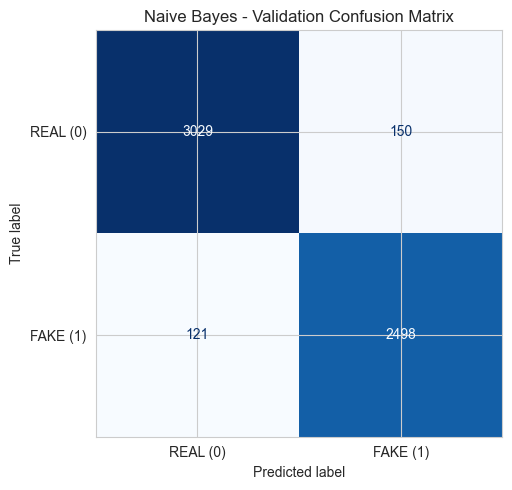

In [6]:
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=LABELS)
fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(cmap="Blues", ax=ax, values_format="d", colorbar=False)
ax.set_title("Naive Bayes - Validation Confusion Matrix")
plt.tight_layout()
plt.savefig(REPORT_DIR / "confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()


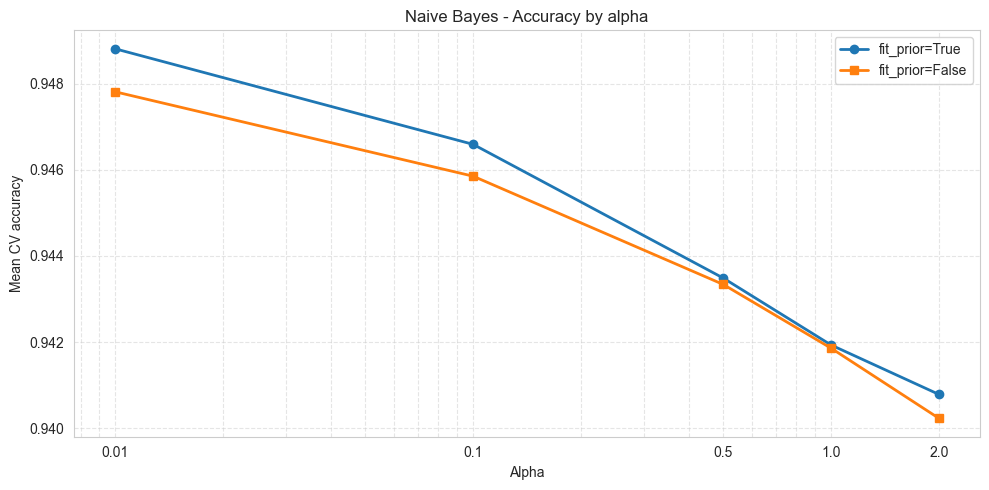

In [7]:
results_true = cv_results[cv_results["param_fit_prior"] == True].sort_values("param_alpha")
results_false = cv_results[cv_results["param_fit_prior"] == False].sort_values("param_alpha")

plt.figure(figsize=(10, 5))
plt.plot(
    results_true["param_alpha"].astype(float),
    results_true["mean_test_score"],
    marker="o",
    label="fit_prior=True",
    linewidth=2,
)
plt.plot(
    results_false["param_alpha"].astype(float),
    results_false["mean_test_score"],
    marker="s",
    label="fit_prior=False",
    linewidth=2,
)
plt.title("Naive Bayes - Accuracy by alpha")
plt.xlabel("Alpha")
plt.ylabel("Mean CV accuracy")
plt.xscale("log")
plt.xticks([0.01, 0.1, 0.5, 1.0, 2.0], ["0.01", "0.1", "0.5", "1.0", "2.0"])
plt.legend()
plt.grid(True, which="both", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.savefig(REPORT_DIR / "alpha_accuracy.png", dpi=150, bbox_inches="tight")
plt.savefig(ROOT / "reports" / "naive_bayes_alpha_tuning.png", dpi=150, bbox_inches="tight")
plt.show()
